# EDA · el precio como problema de clasificación

**De dónde sale este notebook.** `FuncionesMineria.py` está construida casi entera alrededor de
un **target binario**: `mosaico_targetbinaria`, `boxplot_targetbinaria`, `hist_targetbinaria`,
`glm`, `sensEspCorte`, `curva_roc`, `impVariablesLog`. En el notebook 06 se descartaron varias
funciones por no transferir a una serie temporal con target continuo.

Pero hay un encuadre en el que **toda esa mitad de la caja de herramientas sí encaja**, y no es
un apaño: es el encuadre que corresponde al objetivo real del proyecto.

## El argumento

El TFM no acaba en predecir el precio: acaba en **optimizar una batería**. Y para una batería la
decisión no es «¿cuánto valdrá el MWh a las 15:00?», sino **«¿es esta una de las horas en que
conviene cargar, o de las que conviene descargar?»**.

Eso es una decisión de clasificación. Un modelo que se equivoque 15 EUR/MWh en el nivel pero
acierte siempre qué horas son las baratas y cuáles las caras **captura todo el arbitraje**. Y al
revés: uno con MAE excelente que confunda el orden de las horas no sirve para operar.

De hecho `F11_baselines.ipynb` ya apunta a esto: evalúa por MAE **y** por ingreso capturado, y
los rankings no coinciden. Este notebook explora esa segunda dimensión.

**Qué no es esto.** No propone sustituir la regresión por clasificación. Propone mirar el target
también como clase para responder preguntas que la regresión no responde: qué separa una hora
cara de una barata, con qué antelación se puede saber, y cuánto se pierde al fallar.

## Índice

| Bloque | Contenido | Función de clase que reaprovecha |
|---|---|---|
| **A** | Definición de las clases y su estructura temporal | — |
| **B** | Qué distingue una hora cara de una barata | `boxplot_targetbinaria`, `hist_targetbinaria` |
| **C** | Ranking de drivers para la clase | `Vcramer`, `graficoVcramer` |
| **D** | Capacidad de separación y punto de corte | `curva_roc`, `sensEspCorte` |
| **E** | El coste de equivocarse, en euros | — (propio del problema) |

---
## 0 · Carga

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 190)

TZ = "Europe/Madrid"
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
df = pd.read_parquet(RAIZ / "data" / "bronze" / "bronze_unificado.parquet")
df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True)
assert df["ts_utc"].duplicated().sum() == 0, "parquet duplicado: regenerar"

df["ts_local"] = df["ts_utc"].dt.tz_convert(TZ)
df["dia"] = df["ts_local"].dt.date
df["hora"] = df["ts_local"].dt.hour
df["anio"] = df["ts_local"].dt.year
df["dow"] = df["ts_local"].dt.dayofweek
df["mes"] = df["ts_local"].dt.month

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

def pick(d, *c):
    for x in c:
        if x is not None and x in d.columns:
            return x
    return None

PRECIO = pick(df, "spot_es_omie", "es_omie", "spot_es_esios", "spot_es_entsoe")
if PRECIO is None:
    raise SystemExit(
        "Este notebook necesita spot_price en el bronce.\\n"
        "Añadir la entrada de bronze_config_v3.py, reextraer y volver a unir.\\n"
        "Es el hueco nº 1 del EDA: sin target no hay análisis del target."
    )
print(f"Target: {PRECIO} · {df[PRECIO].notna().sum():,} horas con precio")

Target: spot_es_omie · 58,289 horas con precio


---
## A · Definir las clases

**La decisión de método.** ¿Qué es una «hora cara»? Hay dos criterios y dan clases distintas:

- **Absoluto** — precio por encima de un umbral fijo. Problema: el nivel del precio cambia
  radicalmente entre 2020 y 2026, así que un umbral fijo etiqueta años enteros como caros.
- **Relativo al día** — las horas más caras *de su propio día*. Es lo que le importa a la
  batería: carga en las baratas del día y descarga en las caras **del mismo día**, porque no
  puede almacenar de un mes para otro.

**Se usa el relativo**, y no por comodidad: es el que corresponde a la decisión que se va a
tomar. Un día entero caro no da arbitraje si es plano.

In [20]:
K = 4   # nº de horas que la batería carga y descarga cada día

d = df[["ts_utc", "dia", "hora", "dow", "mes", "anio", PRECIO]].dropna(subset=[PRECIO]).copy()
d["rango_dia"] = d.groupby("dia")[PRECIO].rank(method="first")
d["horas_dia"] = d.groupby("dia")[PRECIO].transform("size")

d["clase"] = "intermedia"
d.loc[d["rango_dia"] <= K, "clase"] = "barata"
d.loc[d["rango_dia"] > d["horas_dia"] - K, "clase"] = "cara"
d["es_cara"] = (d["clase"] == "cara").astype(int)

print(d["clase"].value_counts().rename("horas").to_frame().assign(
    pct=lambda x: (x["horas"] / len(d) * 100).round(1)).to_string())

spread = d.groupby("dia").apply(
    lambda g: g.nlargest(K, PRECIO)[PRECIO].mean() - g.nsmallest(K, PRECIO)[PRECIO].mean(),
    include_groups=False)
print(f"\\nDiferencial medio entre las {K} horas caras y las {K} baratas del día: "
      f"{spread.mean():,.2f} EUR/MWh")
print(f"Ese es el ingreso bruto por MWh y por ciclo que un modelo perfecto capturaría.")

            horas   pct
clase                  
intermedia  38857  66.7
barata       9716  16.7
cara         9716  16.7
\nDiferencial medio entre las 4 horas caras y las 4 baratas del día: 61.15 EUR/MWh
Ese es el ingreso bruto por MWh y por ciclo que un modelo perfecto capturaría.


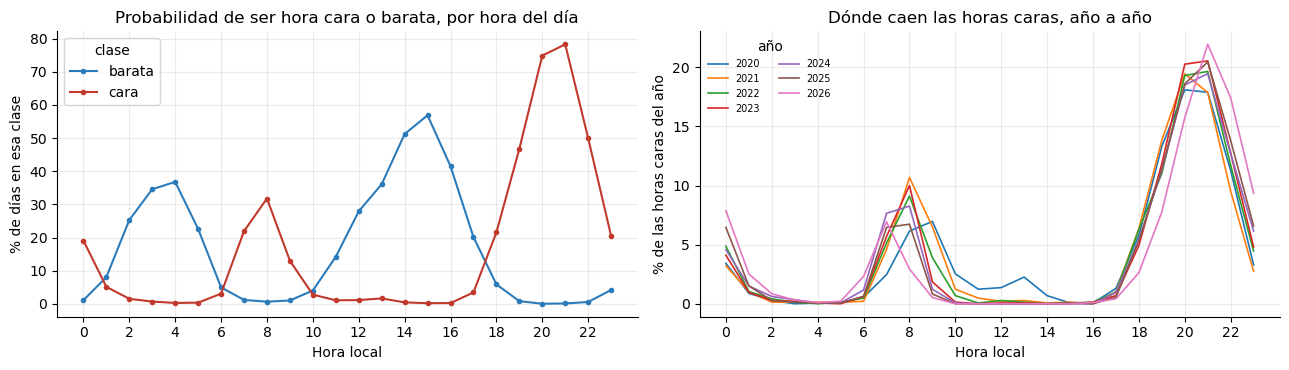

Si la distribución se desplaza año a año, una regla horaria fija envejece mal:
es el argumento para un modelo, y para ponderar los años recientes.


In [21]:
# ¿Cuándo caen las horas caras y las baratas? Si fuera siempre a la misma hora,
# el problema estaría resuelto con una regla fija y no haría falta modelo.
tab = pd.crosstab(d["hora"], d["clase"], normalize="index").mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
tab[["barata", "cara"]].plot(ax=axes[0], marker="o", ms=3,
                             color={"barata": "#2b7bba", "cara": "#c0392b"})
axes[0].set_xlabel("Hora local"); axes[0].set_ylabel("% de días en esa clase")
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_title("Probabilidad de ser hora cara o barata, por hora del día")

por_anio = d[d["clase"] != "intermedia"].pivot_table(
    index="hora", columns=["anio", "clase"], values="es_cara", aggfunc="size").fillna(0)
caras = d[d["clase"] == "cara"].pivot_table(index="hora", columns="anio",
                                            values="es_cara", aggfunc="size").fillna(0)
(caras / caras.sum() * 100).plot(ax=axes[1], lw=1.2)
axes[1].set_xlabel("Hora local"); axes[1].set_ylabel("% de las horas caras del año")
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_title("Dónde caen las horas caras, año a año")
axes[1].legend(title="año", frameon=False, fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

print("Si la distribución se desplaza año a año, una regla horaria fija envejece mal:")
print("es el argumento para un modelo, y para ponderar los años recientes.")

In [22]:
# ¿Cuánta incertidumbre queda si se usara sólo la hora? Es la vara mínima.
mejores = tab["cara"].nlargest(K).index.tolist()
peores = tab["barata"].nlargest(K).index.tolist()
print(f"Regla fija -- descargar en {sorted(mejores)}, cargar en {sorted(peores)}")

acierto_cara = d[d["hora"].isin(mejores)]["es_cara"].mean() * 100
base = d["es_cara"].mean() * 100
print(f"\\nDe las horas de la regla, son realmente caras el {acierto_cara:.1f}%")
print(f"Tasa base (cualquier hora al azar): {base:.1f}%")
print(f"Mejora sobre el azar: x{acierto_cara/base:.2f}")
print("\\nEsto es el suelo: cualquier modelo tiene que superarlo con claridad para justificarse.")

Regla fija -- descargar en [19, 20, 21, 22], cargar en [4, 14, 15, 16]
\nDe las horas de la regla, son realmente caras el 62.5%
Tasa base (cualquier hora al azar): 16.7%
Mejora sobre el azar: x3.75
\nEsto es el suelo: cualquier modelo tiene que superarlo con claridad para justificarse.


---
## B · Qué distingue una hora cara de una barata

**La adaptación de `boxplot_targetbinaria`.** La función de clase compara la distribución de una
variable continua entre los dos niveles del target. Aquí es exactamente lo que hace falta: ver
qué drivers separan las horas caras de las baratas, y cuáles no.

**Y una restricción que la función original no tiene:** se separan las variables por su etiqueta
de fuga. Una variable que separa perfectamente las clases pero no existe a las 12:00 de D no
sirve para decidir nada. Mezclarlas en la misma figura invita a conclusiones inservibles.

In [23]:
DRIVERS = {
    # sin fuga o con desfase: las utilizables
    "demanda prevista":  (pick(df, "forecast_demanda_mercado_prev_mw"), "SIN FUGA"),
    "eólica prevista":   (pick(df, "forecast_gen_wind_prev_mw"), "SIN FUGA"),
    "solar prevista":    (pick(df, "forecast_gen_solar_pv_prev_mw"), "SIN FUGA"),
    "gas":               (pick(df, "tp_ttf_cierre", "commodities_gas_ttf_m1"), "DESFASE D-2"),
    # con fuga: se muestran para contraste, no como candidatas
    "demanda real":      (pick(df, "load_inter_entsoe_load"), "CON FUGA"),
    "eólica real":       (pick(df, "entsoe_wind_mw"), "CON FUGA"),
    "solar FV real":     (pick(df, "calc_solar_fv_mw"), "CON FUGA"),
    "ciclo combinado":   (pick(df, "esios_gen_ree_gccgas_mw"), "CON FUGA"),
    "hidráulica":        (pick(df, "calc_hydro_dispatch_mw"), "CON FUGA"),
    "temperatura":       (pick(df, "era5_t2m_mean"), "CON FUGA (ERA5)"),
}
DRIVERS = {k: v for k, v in DRIVERS.items() if v[0]}
D = d.merge(df[["ts_utc"] + [c for c, _ in DRIVERS.values()]], on="ts_utc", validate="one_to_one")
print(f"{len(DRIVERS)} drivers · {len(D):,} horas")

10 drivers · 58,289 horas


C:\Users\torgi\AppData\Local\Temp\ipykernel_32588\3180512474.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=orden, showfliers=False, patch_artist=True)
C:\Users\torgi\AppData\Local\Temp\ipykernel_32588\3180512474.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=orden, showfliers=False, patch_artist=True)
C:\Users\torgi\AppData\Local\Temp\ipykernel_32588\3180512474.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=orden, showfliers=False, patch_artist=True)
C:\Users\torgi\AppData\Local\Temp\ipykernel_32588\3180512474.py:

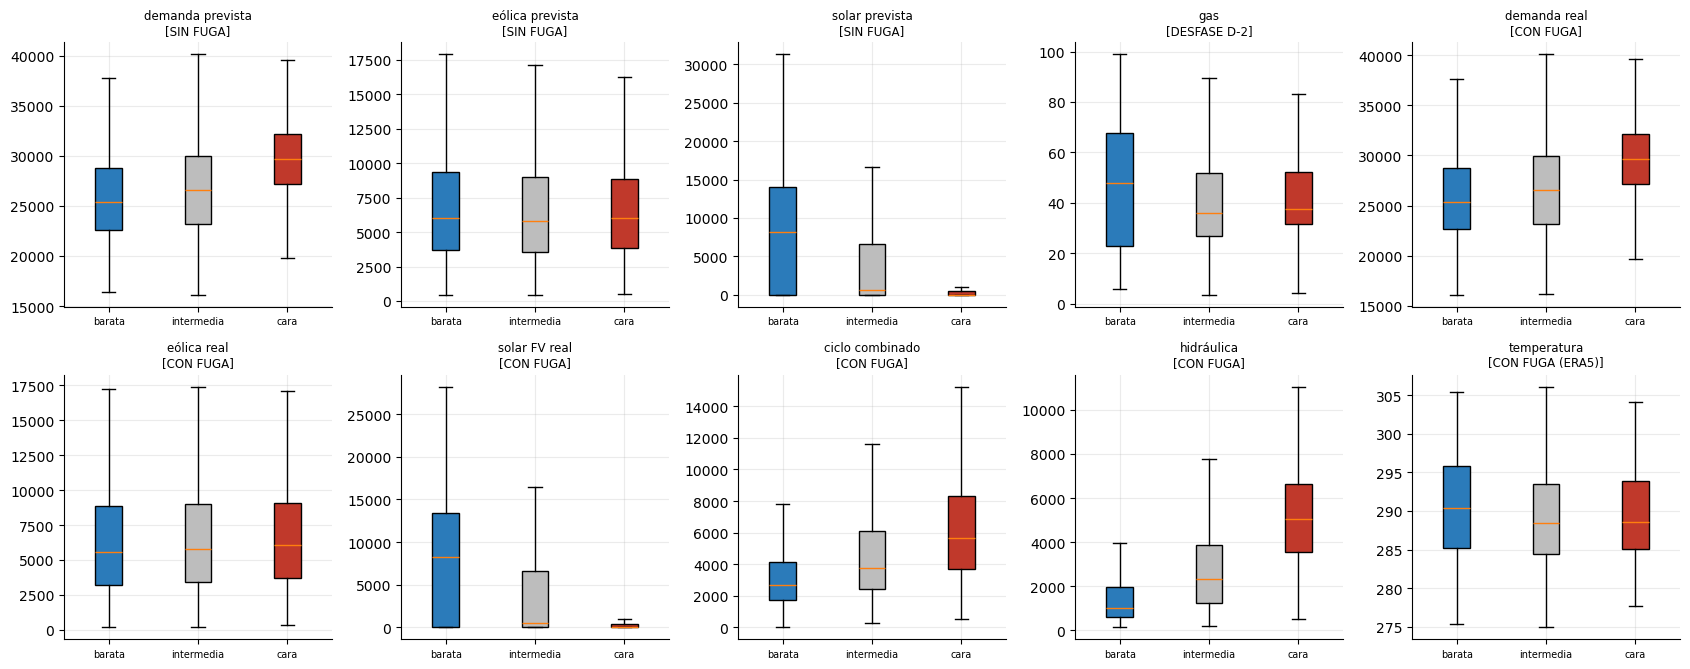

In [24]:
orden = ["barata", "intermedia", "cara"]
colores = {"barata": "#2b7bba", "intermedia": "#bdbdbd", "cara": "#c0392b"}

n = len(DRIVERS)
filas = (n + 4) // 5
fig, axes = plt.subplots(filas, 5, figsize=(17, 3.4 * filas))
for ax, (nombre, (col, fuga)) in zip(np.atleast_1d(axes).ravel(), DRIVERS.items()):
    datos = [D.loc[D["clase"] == c, col].dropna() for c in orden]
    bp = ax.boxplot(datos, labels=orden, showfliers=False, patch_artist=True)
    for parche, c in zip(bp["boxes"], orden):
        parche.set_facecolor(colores[c])
    ax.set_title(f"{nombre}\n[{fuga}]", fontsize=8.5)
    ax.tick_params(axis="x", labelsize=7)
for ax in np.atleast_1d(axes).ravel()[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

In [25]:
# La misma comparación en números: diferencia estandarizada entre caras y baratas.
# Es la d de Cohen, que permite ordenar drivers con escalas muy distintas.
filas_b = []
for nombre, (col, fuga) in DRIVERS.items():
    a = D.loc[D["clase"] == "cara", col].dropna()
    b = D.loc[D["clase"] == "barata", col].dropna()
    if len(a) < 100 or len(b) < 100:
        continue
    s = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    filas_b.append({"driver": nombre, "fuga": fuga,
                    "media cara": a.mean(), "media barata": b.mean(),
                    "d de Cohen": (a.mean() - b.mean()) / s if s else np.nan})

B = pd.DataFrame(filas_b).set_index("driver")
B["|d|"] = B["d de Cohen"].abs()
display(B.sort_values("|d|", ascending=False).round(3))

usables = B[B["fuga"].isin(["SIN FUGA", "DESFASE D-2"])]
print(f"\\nMejor |d| entre las UTILIZABLES: {usables['|d|'].max():.3f} "
      f"({usables['|d|'].idxmax()})")
print(f"Mejor |d| en total:                {B['|d|'].max():.3f} ({B['|d|'].idxmax()})")
print("\\nLa distancia entre ambas cifras es lo que cuesta la restricción de producción,")
print("medida en capacidad de separar horas caras de baratas.")

,fuga,media cara,media barata,d de Cohen,|d|
driver,,,,,
hidráulica,CON FUGA,5130.017,1459.710,2.197,2.197
solar FV real,CON FUGA,579.999,7993.379,-1.453,1.453
solar prevista,SIN FUGA,539.186,8612.043,-1.397,1.397
ciclo combinado,CON FUGA,6247.757,3338.886,1.006,1.006
demanda prevista,SIN FUGA,29688.368,25857.767,0.981,0.981
demanda real,CON FUGA,29685.301,25863.303,0.974,0.974
temperatura,CON FUGA (ERA5),289.582,290.631,-0.170,0.170
eólica real,CON FUGA,6745.271,6354.617,0.101,0.101
eólica prevista,SIN FUGA,6687.062,6903.054,-0.056,0.056


\nMejor |d| entre las UTILIZABLES: 1.397 (solar prevista)
Mejor |d| en total:                2.197 (hidráulica)
\nLa distancia entre ambas cifras es lo que cuesta la restricción de producción,
medida en capacidad de separar horas caras de baratas.


---
## C · Ranking de drivers para la clase

**Reaprovecha `Vcramer` y `graficoVcramer` casi tal cual**, que es el uso para el que se
escribieron: variable continua discretizada contra target categórico. Aquí el target ya es
categórico de verdad, así que la adaptación del notebook 06 ni siquiera hace falta.

**Qué añade sobre el bloque B.** La d de Cohen mide separación **de medias** y supone una
relación monótona. El V de Cramér no supone nada: detecta también los drivers cuya relación con
la clase es no monótona — por ejemplo, uno que sea alto tanto en horas caras como en baratas y
bajo en las intermedias.

,fuga,V de Cramér,|d| de Cohen
driver,,,
hidráulica,CON FUGA,0.3783,2.1967
solar FV real,CON FUGA,0.3309,1.4528
solar prevista,SIN FUGA,0.2941,1.3968
ciclo combinado,CON FUGA,0.2089,1.0065
demanda prevista,SIN FUGA,0.1938,0.9812
demanda real,CON FUGA,0.1937,0.9736
temperatura,CON FUGA (ERA5),0.0814,0.1702
eólica prevista,SIN FUGA,0.0350,0.0559
eólica real,CON FUGA,0.0314,0.1011


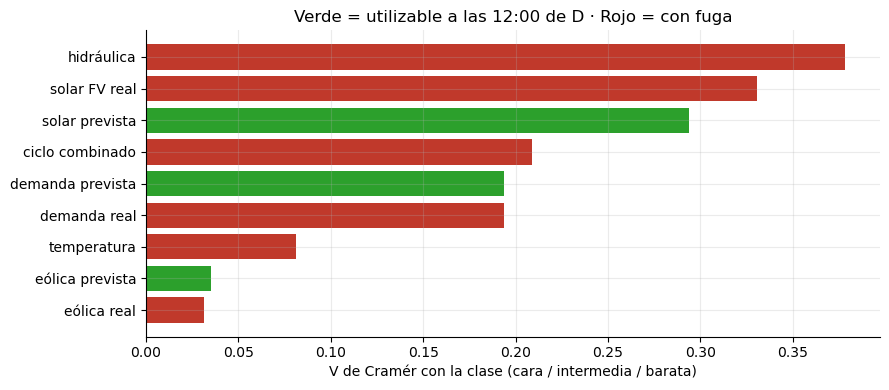

Un driver con V alto y |d| bajo tiene relación NO monótona con la clase: separa,
pero no por 'más es más caro'. Ahí un término lineal no lo aprovecharía.


In [26]:
def v_cramer_cat(v, clase, q=5):
    '''V de Cramér entre una variable continua discretizada y una clase. De FuncionesMineria.'''
    dd = pd.DataFrame({"v": v, "c": clase}).dropna()
    if len(dd) < 200:
        return np.nan
    cortes = sorted(set(dd["v"].quantile(np.linspace(0, 1, q + 1))))
    if len(cortes) < 3:
        return np.nan
    tabla = pd.crosstab(pd.cut(dd["v"], bins=cortes, include_lowest=True), dd["c"])
    chi2 = chi2_contingency(tabla)[0]
    return float(np.sqrt(chi2 / (tabla.sum().sum() * (min(tabla.shape) - 1))))

filas_c = []
for nombre, (col, fuga) in DRIVERS.items():
    filas_c.append({"driver": nombre, "fuga": fuga,
                    "V de Cramér": v_cramer_cat(D[col], D["clase"]),
                    "|d| de Cohen": B.loc[nombre, "|d|"] if nombre in B.index else np.nan})
Cr = pd.DataFrame(filas_c).dropna().set_index("driver").sort_values("V de Cramér", ascending=False)
display(Cr.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
col_barra = ["#2ca02c" if f in ("SIN FUGA", "DESFASE D-2") else "#c0392b" for f in Cr["fuga"]]
ax.barh(Cr.index[::-1], Cr["V de Cramér"][::-1], color=col_barra[::-1])
ax.set_xlabel("V de Cramér con la clase (cara / intermedia / barata)")
ax.set_title("Verde = utilizable a las 12:00 de D · Rojo = con fuga")
plt.tight_layout(); plt.show()

print("Un driver con V alto y |d| bajo tiene relación NO monótona con la clase: separa,")
print("pero no por 'más es más caro'. Ahí un término lineal no lo aprovecharía.")

---
## D · Capacidad de separación y punto de corte

**Reaprovecha `curva_roc` y `sensEspCorte`.** La curva ROC mide, sin fijar ningún umbral, cuánto
separa un driver las horas caras del resto. El AUC resume esa capacidad en un número: 0,5 es
azar, 1 es separación perfecta.

**Por qué es la métrica adecuada para este encuadre.** No depende de dónde se ponga el corte, así
que compara drivers con escalas y distribuciones distintas sin tener que elegir umbral primero.
Y el punto de corte óptimo sí tiene lectura operativa: es el valor del driver a partir del cual
conviene actuar.

In [27]:
from sklearn.metrics import roc_auc_score, roc_curve

y = D["es_cara"]
filas_d = []
for nombre, (col, fuga) in DRIVERS.items():
    m = D[col].notna()
    if m.sum() < 500 or y[m].nunique() < 2:
        continue
    auc = roc_auc_score(y[m], D.loc[m, col])
    # Un driver puede separar "al revés": AUC < 0,5 significa que valores bajos indican cara.
    filas_d.append({"driver": nombre, "fuga": fuga, "AUC": auc,
                    "AUC ajustado": max(auc, 1 - auc),
                    "sentido": "alto = cara" if auc >= 0.5 else "bajo = cara"})
A = pd.DataFrame(filas_d).set_index("driver").sort_values("AUC ajustado", ascending=False)
display(A.round(4))

,fuga,AUC,AUC ajustado,sentido
driver,,,,
hidráulica,CON FUGA,0.8373,0.8373,alto = cara
demanda prevista,SIN FUGA,0.7078,0.7078,alto = cara
demanda real,CON FUGA,0.7075,0.7075,alto = cara
ciclo combinado,CON FUGA,0.6843,0.6843,alto = cara
solar prevista,SIN FUGA,0.3364,0.6636,bajo = cara
solar FV real,CON FUGA,0.3548,0.6452,bajo = cara
gas,DESFASE D-2,0.5476,0.5476,alto = cara
eólica real,CON FUGA,0.5208,0.5208,alto = cara
eólica prevista,SIN FUGA,0.5108,0.5108,alto = cara


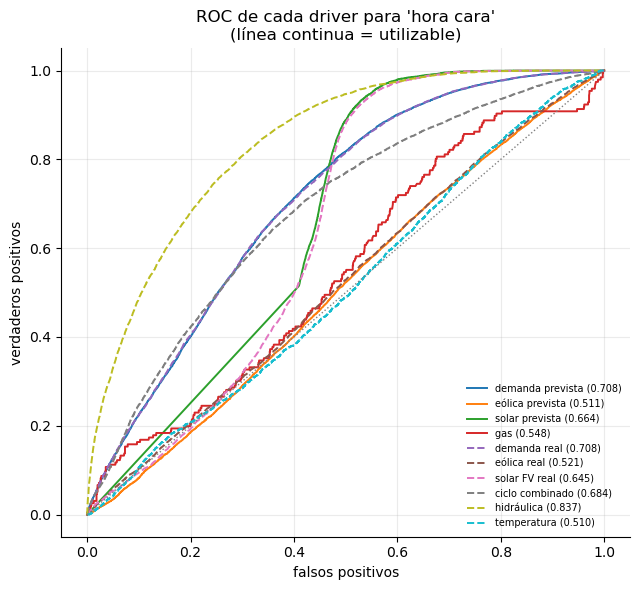

In [28]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for nombre, (col, fuga) in DRIVERS.items():
    if nombre not in A.index:
        continue
    m = D[col].notna()
    score = D.loc[m, col] if A.loc[nombre, "AUC"] >= 0.5 else -D.loc[m, col]
    fpr, tpr, _ = roc_curve(y[m], score)
    estilo = "-" if fuga in ("SIN FUGA", "DESFASE D-2") else "--"
    ax.plot(fpr, tpr, estilo, lw=1.4,
            label=f"{nombre} ({A.loc[nombre, 'AUC ajustado']:.3f})")
ax.plot([0, 1], [0, 1], color="grey", lw=1, ls=":")
ax.set_xlabel("falsos positivos"); ax.set_ylabel("verdaderos positivos")
ax.set_title("ROC de cada driver para 'hora cara'\n(línea continua = utilizable)")
ax.legend(frameon=False, fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

In [29]:
# Punto de corte: el que maximiza sensibilidad + especificidad (índice de Youden).
mejor = A[A["fuga"].isin(["SIN FUGA", "DESFASE D-2"])].index[0]
col = DRIVERS[mejor][0]
m = D[col].notna()
score = D.loc[m, col] if A.loc[mejor, "AUC"] >= 0.5 else -D.loc[m, col]
fpr, tpr, umbrales = roc_curve(y[m], score)
j = np.argmax(tpr - fpr)
corte = umbrales[j] if A.loc[mejor, "AUC"] >= 0.5 else -umbrales[j]

print(f"Mejor driver utilizable: {mejor} ({col})")
print(f"Corte óptimo (Youden): {corte:,.1f}")
print(f"  sensibilidad {tpr[j]*100:.1f}% · especificidad {(1-fpr[j])*100:.1f}%")

pred = (D[col] >= corte) if A.loc[mejor, "AUC"] >= 0.5 else (D[col] <= corte)
conf = pd.crosstab(pred.rename("predicho cara"), D["es_cara"].rename("es cara"))
display(conf)
print("\\nUn solo driver y un umbral. Es la referencia mínima: el modelo tiene que")
print("mejorar esto de forma clara, o no está aportando nada.")

Mejor driver utilizable: demanda prevista (forecast_demanda_mercado_prev_mw)
Corte óptimo (Youden): 26,524.8
  sensibilidad 80.4% · especificidad 51.6%


es cara,0,1
predicho cara,,
False,25068,1900
True,23505,7816


\nUn solo driver y un umbral. Es la referencia mínima: el modelo tiene que
mejorar esto de forma clara, o no está aportando nada.


---
## E · El coste de equivocarse, en euros

**Lo que ninguna función de clase puede dar**, porque depende del problema: no todos los errores
cuestan lo mismo. Confundir una hora cara con una intermedia cuesta poco; confundirla con una
barata cuesta el diferencial entero, y además dos veces — se deja de ganar y se paga por cargar
cuando había que descargar.

**Por qué cierra este notebook.** Convierte la matriz de confusión en la unidad en que se mide
el TFM. Es la conexión explícita entre el EDA del precio y la optimización del BESS.

In [30]:
precio_medio = D.groupby("clase")[PRECIO].mean()
print("Precio medio por clase (EUR/MWh):")
display(precio_medio.round(2).to_frame())

# Matriz de coste: euros por MWh perdidos al confundir la clase real con la predicha.
clases = ["barata", "intermedia", "cara"]
COSTE = pd.DataFrame(
    [[abs(precio_medio[real] - precio_medio[pred]) for pred in clases] for real in clases],
    index=[f"real {c}" for c in clases], columns=[f"predicho {c}" for c in clases])
display(COSTE.round(2))

print(f"\\nEl error más caro es confundir cara con barata: "
      f"{COSTE.loc['real cara', 'predicho barata']:,.2f} EUR/MWh.")
print(f"Confundir cara con intermedia cuesta "
      f"{COSTE.loc['real cara', 'predicho intermedia']:,.2f} EUR/MWh, "
      f"{COSTE.loc['real cara','predicho barata']/max(COSTE.loc['real cara','predicho intermedia'],1e-9):.1f}x menos.")
print("\\nConsecuencia para la evaluación del modelo: una métrica que trate todos los errores")
print("por igual (como el MAE) no refleja el valor operativo. Es exactamente lo que ya")
print("mostraba F11_baselines al ver que el ranking por MAE y por dinero no coinciden.")

Precio medio por clase (EUR/MWh):


,spot_es_omie
clase,
barata,56.61
cara,117.76
intermedia,85.16


,predicho barata,predicho intermedia,predicho cara
real barata,0.00,28.55,61.15
real intermedia,28.55,0.00,32.60
real cara,61.15,32.60,0.00


\nEl error más caro es confundir cara con barata: 61.15 EUR/MWh.
Confundir cara con intermedia cuesta 32.60 EUR/MWh, 1.9x menos.
\nConsecuencia para la evaluación del modelo: una métrica que trate todos los errores
por igual (como el MAE) no refleja el valor operativo. Es exactamente lo que ya
mostraba F11_baselines al ver que el ranking por MAE y por dinero no coinciden.


Ingreso diario medio por MWh de batería:
  previsión perfecta :   244.59 EUR
  regla horaria fija :   175.61 EUR (71.8% del techo)


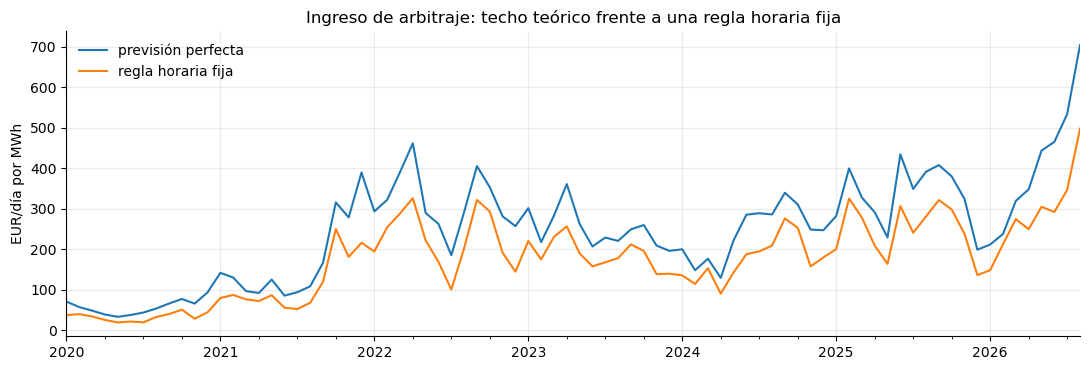

\nEse porcentaje es la vara real del proyecto: lo que un modelo tiene que superar
para justificar su existencia frente a 'descarga siempre a las mismas horas'.


In [31]:
# ¿Cuánto del arbitraje teórico captura la regla horaria fija del bloque A?
def ingreso(seleccion_carga, seleccion_descarga, g):
    return g.loc[seleccion_descarga, PRECIO].sum() - g.loc[seleccion_carga, PRECIO].sum()

filas_e = []
for dia, g in D.groupby("dia"):
    if len(g) < 20:
        continue
    perfecto = ingreso(g.nsmallest(K, PRECIO).index, g.nlargest(K, PRECIO).index, g)
    regla_c = g[g["hora"].isin(peores)].index[:K]
    regla_d = g[g["hora"].isin(mejores)].index[:K]
    if len(regla_c) < K or len(regla_d) < K:
        continue
    filas_e.append({"dia": dia, "perfecto": perfecto, "regla": ingreso(regla_c, regla_d, g)})

E = pd.DataFrame(filas_e).set_index("dia")
E.index = pd.to_datetime(E.index)
print(f"Ingreso diario medio por MWh de batería:")
print(f"  previsión perfecta : {E['perfecto'].mean():>8,.2f} EUR")
print(f"  regla horaria fija : {E['regla'].mean():>8,.2f} EUR "
      f"({E['regla'].sum()/E['perfecto'].sum()*100:.1f}% del techo)")

ax = E.resample("MS").mean().plot(figsize=(11, 3.8))
ax.set_ylabel("EUR/día por MWh"); ax.set_xlabel("")
ax.set_title("Ingreso de arbitraje: techo teórico frente a una regla horaria fija")
ax.legend(["previsión perfecta", "regla horaria fija"], frameon=False)
plt.tight_layout(); plt.show()

print("\\nEse porcentaje es la vara real del proyecto: lo que un modelo tiene que superar")
print("para justificar su existencia frente a 'descarga siempre a las mismas horas'.")

---
## Cierre

In [32]:
for l in [
    "QUÉ APORTA ESTE ENCUADRE",
    "=" * 66,
    "",
    "1. Recupera la mitad de FuncionesMineria.py que el notebook 06 había descartado.",
    "   No por reaprovechar código, sino porque el problema de la batería ES una",
    "   decisión de clasificación: qué horas cargar y cuáles descargar.",
    "",
    "2. Da una vara de referencia que la regresión no da: cuánto arbitraje captura",
    "   una regla horaria fija. Un modelo que no supere eso con claridad no aporta,",
    "   por bueno que sea su MAE.",
    "",
    "3. Separa los drivers por etiqueta de fuga en TODAS las figuras. La distancia",
    "   entre el mejor driver utilizable y el mejor con fuga mide, en capacidad de",
    "   separación, lo que cuesta la restricción de producción.",
    "",
    "4. Cuantifica en euros el coste de cada tipo de error. Confundir una hora cara",
    "   con una barata no cuesta lo mismo que confundirla con una intermedia, y una",
    "   métrica simétrica como el MAE no lo recoge.",
    "",
    "LÍMITES, para no venderlo de más:",
    "",
    "  · Las clases se definen sobre el precio REAL del propio día, así que este",
    "    análisis es descriptivo. En producción hay que predecir la clase, no",
    "    observarla.",
    "  · La regla horaria fija se evalúa sobre el mismo período en que se eligieron",
    "    sus horas: está sobreajustada por construcción. Para usarla como baseline",
    "    honesto hay que elegir las horas en train y evaluarlas en test.",
    "  · K = 4 horas de carga y descarga es un supuesto. Con otra profundidad de",
    "    batería, las cifras cambian.",
]:
    print(l)

QUÉ APORTA ESTE ENCUADRE

1. Recupera la mitad de FuncionesMineria.py que el notebook 06 había descartado.
   No por reaprovechar código, sino porque el problema de la batería ES una
   decisión de clasificación: qué horas cargar y cuáles descargar.

2. Da una vara de referencia que la regresión no da: cuánto arbitraje captura
   una regla horaria fija. Un modelo que no supere eso con claridad no aporta,
   por bueno que sea su MAE.

3. Separa los drivers por etiqueta de fuga en TODAS las figuras. La distancia
   entre el mejor driver utilizable y el mejor con fuga mide, en capacidad de
   separación, lo que cuesta la restricción de producción.

4. Cuantifica en euros el coste de cada tipo de error. Confundir una hora cara
   con una barata no cuesta lo mismo que confundirla con una intermedia, y una
   métrica simétrica como el MAE no lo recoge.

LÍMITES, para no venderlo de más:

  · Las clases se definen sobre el precio REAL del propio día, así que este
    análisis es descriptivo. 